# HW 15 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 9th, 2025 at 11:59pm** on Gradescope

## 1 Modify the Animation from Lecture
Modify the given sine wave animation so that the wave moves twice as fast. What parts of the code you you need to change, and why? Please specifically highlight this in your code

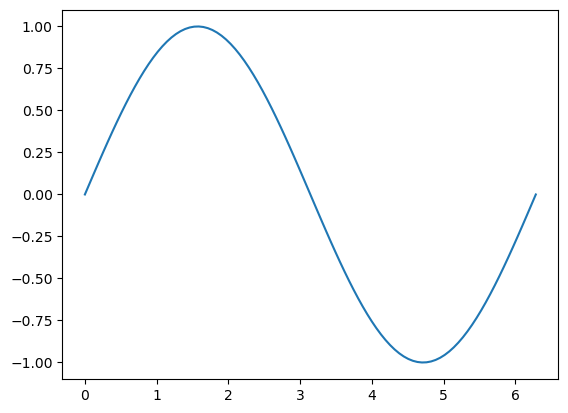

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
x = np.linspace(0, 2 * np.pi, 100)


fig, ax = plt.subplots()

line, = ax.plot(x, np.sin(x))

def update(frame):
    line.set_ydata(np.sin(x + frame / 5)) #Changed from / 10 to / 5 in order to make the animation move twice as fast
    return line,

ani = animation.FuncAnimation(fig, update, frames = 100, interval=25, blit = True)
# Changed interval from 50 to 25 to make the animation update twice as frequently
plt.show()

In [ ]:
# Your comment here

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [3]:
ani.save("animation1.mp4", writer="ffmpeg", fps=20)

Explain what happens if you set `blit=True` in `FuncAnimation`? What happens if you set it to `blit=False`?

In [6]:
# blit = true means only parts of the plot that are changed are redrawn,
# blit = false means the entire plot is redrawn in every frame

## 2 A Different Animation
Write an animation where a dot moves in a circular path instead of sine wave. *Hint: You will need to use `np.sin` and `np.cos`. 

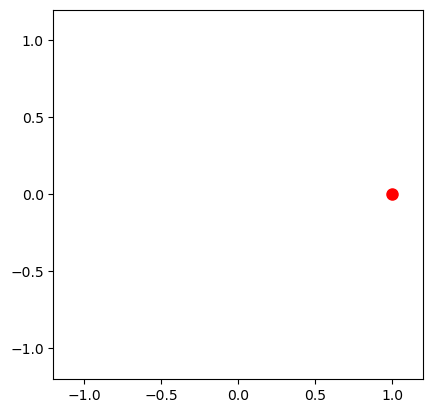

In [10]:

# Define the figure and axis
fig, ax = plt.subplots()
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')  # Keep the aspect ratio square

# Initialize a point (dot) at (1,0)
dot, = ax.plot([], [], 'ro', markersize=8)  # 'ro' = red dot

# Function to update the dot's position
def update(frame):
    theta = frame * (2 * np.pi / 100)  # Angle changes over time
    x = np.cos(theta)
    y = np.sin(theta)
    dot.set_data([x], [y])  # Wrap x and y in lists
    return dot,

# Create the animation
ani = animation.FuncAnimation(fig, update, frames=100, interval=50, blit=True)

plt.show()


Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [11]:
ani.save("animation12.mp4", writer="ffmpeg", fps=20)

## 3 Simulate Orbital Motion of Planets and a Comet
**Check out the `example_solar_system_animation.mp4` as an example of what you will be creating in this problem.**

Now you will simulate and visualize the orbital motion of Earth, Mars and a coment around the Sun using Newtonian gravity and Python. Here are the steps:
* Calculate the gravitational forces acting on each body.
* Update positions and velocities over time.
* Simulate the motion of these celestial bodies over a period of 5 years.
* Animate the results to observe orbital patterns. 

Let's dig a bit into the physics. The motion of celestial bodies follows **Newton's laws of motion and gravitation**:
$$
F = G \frac{m_1 m_1}{r^2}
$$

where:
* $F$ is the gravitational force.
* $G = 6.67\times10^{-11}$ is the gravitational constant
* $m_1$, $m_2$ are the measses of the two objects.
* $r$ is the distance between them.

Using **Newton's Second Law**, the acceleration is given by:

$$
a = \frac{F}{m}
$$

where $a$ is the acceleration, and $m$ is the object's mass. The velocity and position are updated with numerical integration:

$$
v = v + a \cdot dt
$$

$$
x = x + v \cdot dt
$$

## 3.1 Implementing the Simulation
Goal: Set up the **masses**, **initial positions** and **velocities** for the Sun, Earth, Mars and a comet. 
* Use SI units (meters, kilograms, seconds).
* The Sun is at the origin (0, 0, 0)
* Earth, Mars and the commet start at **aphelion** (farthest from the Sun).

Start by defining the following initial variables in kilograms (or SI units):
* `G`
* `Ms` (the mass of the Sun, you will need to google this)
* `Me` (the mass of the Earth)
* `Mm` (the mass of Mars)
* `Mc = 6.39e20` (the mass of a comet)
* `AU` (astronomical unit, distance between Earth and the Sun)
* `daysec` (how many seconds are in a day)

In [12]:
# Gravitational constant (m^3 kg^-1 s^-2)
G = 6.67430e-11  

# Masses of celestial bodies (kg)
Ms = 1.989e30   # Mass of the Sun
Me = 5.972e24   # Mass of the Earth
Mm = 6.417e23   # Mass of Mars
Mc = 6.39e20    # Mass of the comet

# Astronomical unit (meters) - Average Earth-Sun distance
AU = 1.496e11  

# Seconds in a day
daysec = 86400  


Now we will define some initial velocities in meters per second:
* `e_ap_v` (Earth at aphelion, google it, make sure its in SI units)
* `m_ap_v` (Mars at aphelion)
* `commet_v = 7000` (speed of the comet)

In [13]:
# Earth's velocity at aphelion (m/s)
e_ap_v = 29.29e3  # 29.29 km/s converted to m/s

# Mars' velocity at aphelion (m/s)
m_ap_v = 21.97e3  # 21.97 km/s converted to m/s

# Comet's velocity (m/s)
comet_v = 7000  # Given as 7000 m/s


Run the cell below to define some gravitational constants because we expect no mass loss:

In [14]:
# Gravitational parameters (m^3/s^2)
GMs = G * Ms  # Sun's gravitational parameter
GMe = G * Me  # Earth's gravitational parameter
GMm = G * Mm  # Mars' gravitational parameter
GMc = G * Mc  # Comet's gravitational parameter

Define the initial positions of the Earth, Mars and the comet. Here is the Earth as an example:
* `xe, ye, ze = 1.0167 * AU, 0, 0`

Follow the same pattern for Mars (where the `x` coordinate is at `1.666 * AU`, everything else is zero) and the comet (where the `x` coordinate is at `2* AU`, the `y` coordinate is `0.3 * AU` and the `z` coordinate is zero) . Remember the sun is at the origin! 

In [15]:
# Initial positions (meters)
xe, ye, ze = 1.0167 * AU, 0, 0  # Earth
xm, ym, zm = 1.666 * AU, 0, 0   # Mars
xc, yc, zc = 2 * AU, 0.3 * AU, 0  # Comet


We will do the same thing but for initial velocities. Here is Earth as an example:
* `xve, yve, zve = 0, e_ap_v, 0`

Make variables for Mars but with `m_ap_v` as the `y` coordinate. Make variables for the commet but with `commet_v` as the `y` coordinate.

In [17]:
# Initial velocities (m/s)
xve, yve, zve = 0, e_ap_v, 0  # Earth
xvm, yvm, zvm = 0, m_ap_v, 0  # Mars
xvc, yvc, zvc = 0, comet_v, 0  # Comet

Assume the Sun is at the origin. Make initial positions and velocities for the Sun. It should not be moving so all its velocities coordinates are zero. 

In [18]:
# Initial position and velocity of the Sun (stationary at the origin)
xS, yS, zS = 0, 0, 0  # Position at the origin
xvS, yvS, zvS = 0, 0, 0  # Velocity is zero


Now we will define some time parameters for our simulation. Create variable for the initial time `t` and set it to zero. Create a variable called `dt` for the change in time (steps per day) and set it to `1 * daysec`. Create a varible for `years` and set it to `5`. Finally, create a varible for `sim_years` and set it equal to `years * 365 * daysec`.

In [ ]:
# Initial time (seconds)
t = 0

# Time step (1 second per day, in seconds)
dt = 1 * daysec  # 1 second per day

# Total years for the simulation
years = 5

# Total simulation time in seconds (5 years)
sim_years = years * 365 * daysec  # 365 days per year


Create empty lists to store all of your varibles. Run the cell below.

In [19]:
# Create empty lists to store variables
positions = []  # For storing positions (e.g., Earth, Mars, Comet, Sun)
velocities = []  # For storing velocities (e.g., Earth, Mars, Comet, Sun)
times = []  # For storing the time steps


## 3.2 Compute Gravitational Forces and Update Positions
Goal:
* Implement the **gravitational force equation** to calculate the force acting on each body.
* Compute accelerations using $a = F/m$.
* Update **velocity** and **position**.
* Use a loop to update positions over **5 years**.
* Store the results in lists for plotting.

I will do this part for you, it requires some physics knowledge. But you need to turn this into a loop for when time is less than the simulation time. You want the loop to repeat it itself until that condition is met. 

In [25]:
# Your code here
################ Earth #############
rx, ry, rz = xe - xS, ye - yS, ze - zS
modr3_e = (rx**2 + ry**2 + rz**2)**1.5
fx_e = -GMe * rx / modr3_e
fy_e = -GMe * ry / modr3_e
    
xve += fx_e * dt / Me
yve += fy_e * dt / Me
xe += xve * dt
ye += yve * dt
    
xelist.append(xe)
yelist.append(ye)

################ Mars ##############
rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
fx_m = -gravconst_m * rx_m / modr3_m
fy_m = -gravconst_m * ry_m / modr3_m
    
xvm += fx_m * dt / Mm
yvm += fy_m * dt / Mm
xm += xvm * dt
ym += yvm * dt
    
xmlist.append(xm)
ymlist.append(ym)

################ Comet ##############
rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
fx_c = -gravconst_c * rx_c / modr3_c
fy_c = -gravconst_c * ry_c / modr3_c
    
xvc += fx_c * dt / Mc
yvc += fy_c * dt / Mc
xc += xvc * dt
yc += yvc * dt
    
xclist.append(xc)
yclist.append(yc)

################ Sun ##############
xvs += -(fx_e + fx_m) * dt / Ms
yvs += -(fy_e + fy_m) * dt / Ms
xs += xvs * dt
ys += yvs * dt
xslist.append(xs)
yslist.append(ys)

t += dt

NameError: name 'dt' is not defined

## 3.3 Visualization
Goal: Plot the Orbits
* After simulating the motion, **plot the orbits of Earth, Mars and the comet**.
* Label the **Sun**, **Earth**, **Mars**, and **Comet**.

Start by making a figure, set the argument of`figsize=(8, 8)`.
* Plot the `yelist` as a function of `xelist`. Do this for the `xm`, `xc` and `xs` lists as well. Make sure each line is a **different color**!
  * The Sun will just be a point, so give it a markersize of `10`. Make it yellow.  
* Give it a legend
* Add an `xlabel` of `"X Position (m)"`.
* Add an `ylabel` of `"Y Position (m)"`.
* Give it a title.
* Add a grid.
* Show the plot.

In [ ]:
# Your code here 

Goal: Animate the Motion
* Create an animated visualization of planetary orbits.
* Track the motion of each body over time.

\
Follow the procedure from lecture. Here are some hints:
* Set the `x` and `y` limits to `-3 * AU` to `3 * AU`. \


* Unpack the lines for Earth, Mars, the commet. Example: 
  * `line_e = axplot([], [], '-g', lw=1)` \

  
* Unpack the points for Earth, Mars, the commet and the Sun. Example:
  * `point_e, = ax.plot([],[],'bo',markersize=4)` \

* Give a title to each of the objects. Example:
  * `text_e  = ax.text(AU,0,'Earth')`

* Create the `update` function and update the lines, points and text you just unpacked. Example:
  * `line_e.set_data(xelist[:i], yelist[:i])` 
  * `point_e.set_data(xelist[i], yelist[i])`\
  * `text_e.set_position((xelist[i],yelist[i]))`


* Create the animation! Set `frames = len(xelist)`, `interval=1` and `blit=True`. 

In [ ]:
# Your code here

## 3.4 Add Mercury, Venus and the Moon!
As an extra challenge, give your best attempt at simulating Mercury, Venus and/or the Moon! I am not going to give you a ton of hints for this problem. Come to office hours if you have questions :)

In [ ]:
# Your code here

Save you animation as a `.gif` or as a `.mp4`. Include this in your submission! This may take up to a couple mintutes!

In [ ]:
# Your code here
anim.save("animation100.mp4", writer="ffmpeg", fps=20)

Upload this notebook and your animations to Gradescope!